1. **Notebook 1:**
 
   - Explorar diferentes técnicas de convolución para preprocesar las imágenes.
   - Implementar y evaluar el filtro gaussiano.
   - Probar otros métodos si es necesario.



## Imports


In [12]:
import os
import sunpy.map
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


##  Ruta a las IMG

In [13]:
# Ruta base a tus imágenes
base_dir = "/home/alyonaivanova/personal/SOLAR/data/multichannel_SDO_AIA/"
# Definir los canales
channels = ["131.0Å", "171.0Å", "193.0Å", "211.0Å", "304.0Å", "335.0Å", "1600.0Å", "1700.0Å", "4500.0Å"]

## Mascara

Observamos que los pixeles afuera del disco solar solo generaran ruido, entonces para
solucionar est voamos a implementar una máscara circular para eliminar los píxeles que no pertenecen
al disco solar. Usaremos la tabla de metadatos para determinar el radio del Sol en 
píxeles y crear la máscara.


### Pasos
1. **Calcular el radio del Sol en píxeles**:
   - Usamos el metadato `R_SUN` y la escala en píxeles (`CDELT1` o `CDELT2`).
2. **Crear la máscara circular**:
   - Usaremos la ecuación del círculo:
     \[
     (x - x_{\text{centro}})^2 + (y - y_{\text{centro}})^2 < R^2
     \]
3. **Aplicar la máscara**:
   - Establecemos los píxeles fuera del círculo como `NaN` o `0`.

In [14]:
def create_circular_mask(data, metadata):
    """
    Crea una máscara circular adaptada al disco solar en los datos.
    """
    ny, nx = data.shape
    x_center = nx // 2
    y_center = ny // 2
    
    # Determinar el radio del Sol en píxeles usando cdelt1 y cdelt2
    cdelt1 = metadata.get("cdelt1", 1.0)  # Arcsec/píxel en X
    solar_radius_arcsec = metadata.get("rsun_obs", 960.0)  # Radio solar en arcsec
    solar_radius_pixels = int(solar_radius_arcsec / cdelt1)

    # Crear las coordenadas de la malla
    y, x = np.ogrid[:ny, :nx]
    distance_from_center = np.sqrt((x - x_center)**2 + (y - y_center)**2)

    # Crear la máscara
    mask = distance_from_center <= solar_radius_pixels
    return mask


In [15]:
channel_properties = {
    "131.0Å": {"cmap": "Blues", "description": "10 million K (Flare Plasma)"},
    "171.0Å": {"cmap": "YlGnBu", "description": "1 million K (Quiet Corona)"},
    "193.0Å": {"cmap": "Oranges", "description": "1.25 million K (Active Corona)"},
    "211.0Å": {"cmap": "Reds", "description": "2 million K (Hot Corona)"},
    "304.0Å": {"cmap": "PuRd", "description": "50,000 K (Chromosphere/Transition Region)"},
    "335.0Å": {"cmap": "Purples", "description": "2.5 million K (Active Region Corona)"},
    "1600.0Å": {"cmap": "pink", "description": "6,000 K (Transition Region)"},
    "1700.0Å": {"cmap": "Greys", "description": "5,000 K (Photosphere)"},
    "4500.0Å": {"cmap": "coolwarm", "description": "6,000 K (Photosphere Continuum)"}
}

channels = list(channel_properties.keys())

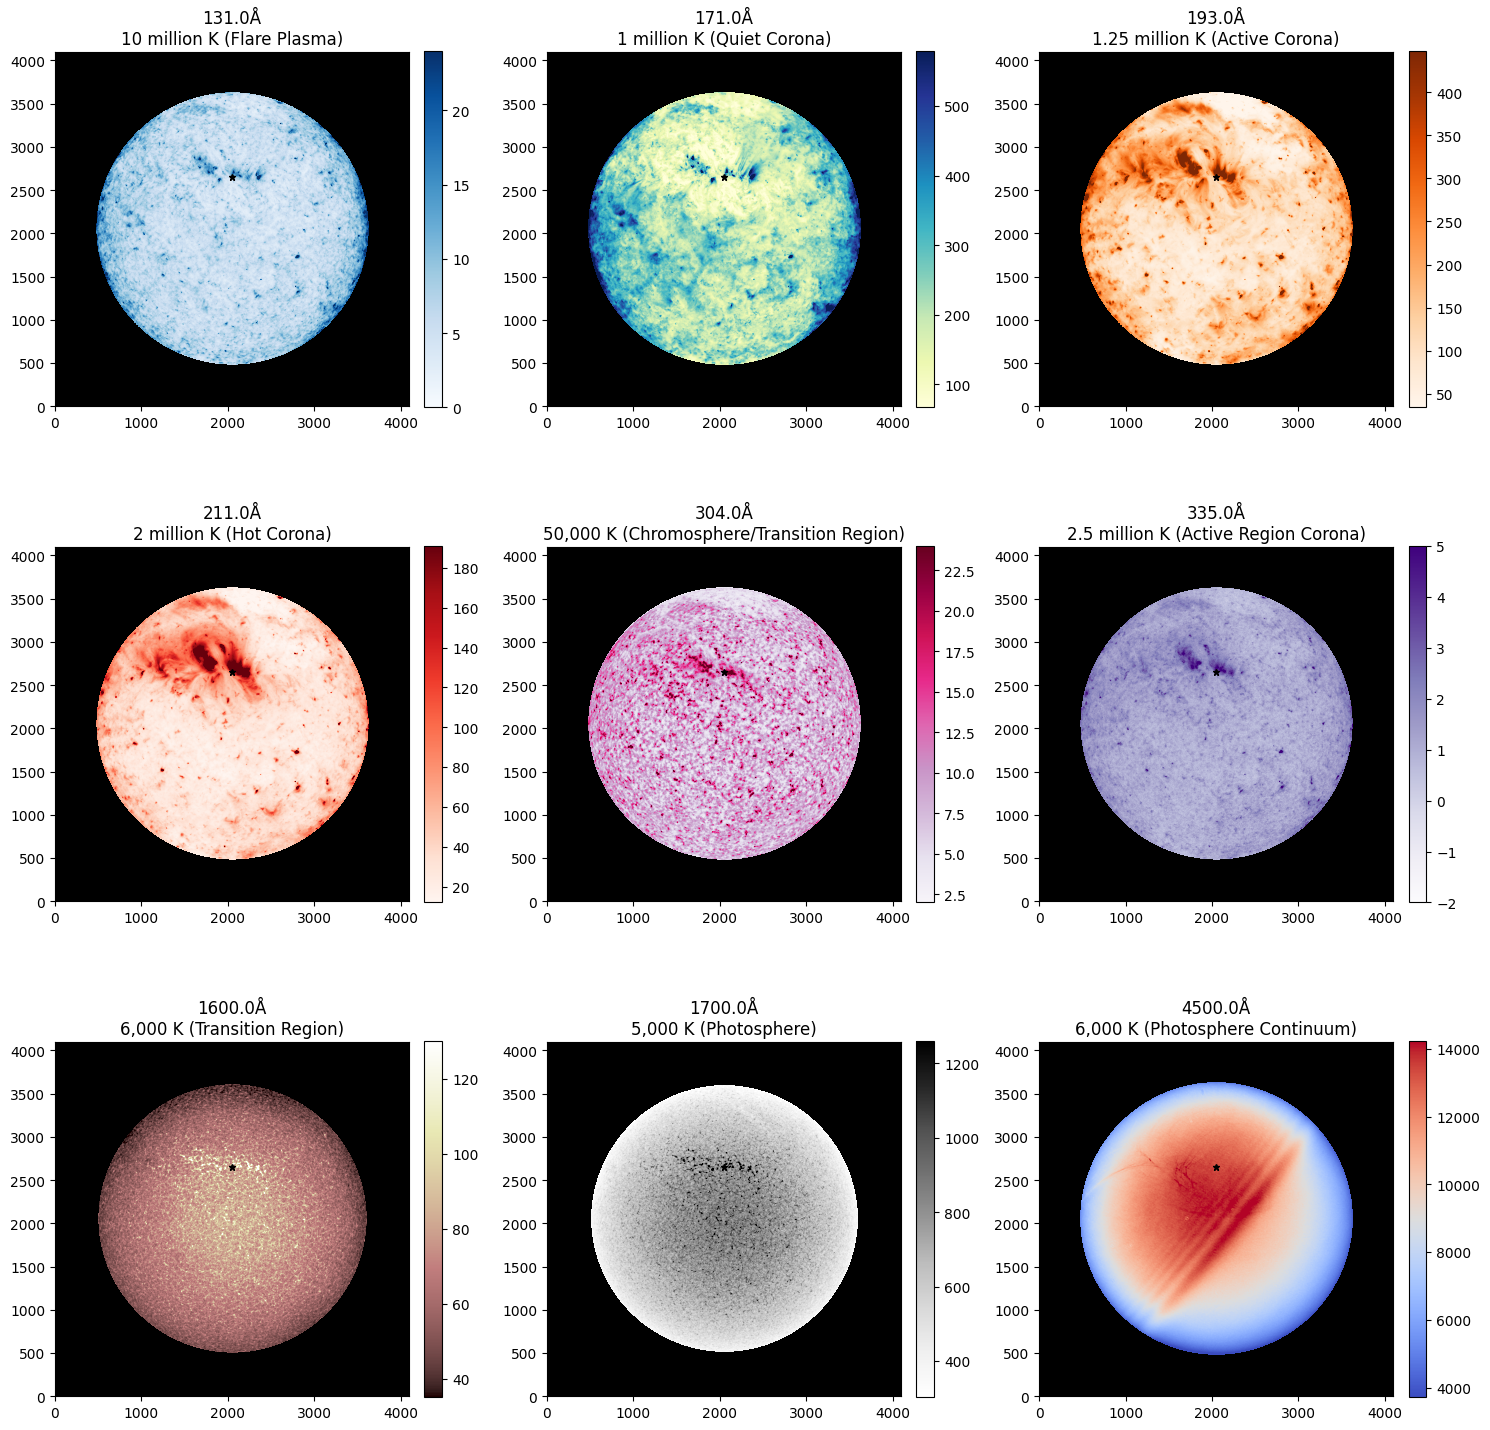

In [16]:
channel_data_process = {}

def process_and_plot_image_with_mask(channel, ax):
    channel_dir = os.path.join(base_dir, channel)
    fits_files = [f for f in os.listdir(channel_dir) if f.endswith(".fits")]
    
    if fits_files:  # Verificar si hay archivos FITS
        fits_path = os.path.join(channel_dir, fits_files[0])
        aia_map = sunpy.map.Map(fits_path)
        data = aia_map.data  # Obtener el arreglo numpy 2D
        
        # Crear máscara circular
        mask = create_circular_mask(data, aia_map.meta)
        masked_data = data.copy()  # Copiar los datos originales
        masked_data[~mask] = np.nan  # Aplicar la máscara: fuera del círculo -> NaN
        
        
        # Guardar los datos aplanados para scatter plots
        channel_data_process[channel] = masked_data.flatten()
        
        # Establecer límites de visualización (vmin, vmax)
        vmin = np.nanpercentile(masked_data, 1)  # 1er percentil (ignorando NaN)
        vmax = np.nanpercentile(masked_data, 99)  # 99º percentil (ignorando NaN)
        
        # Configurar el fondo negro para el eje
        ax.set_facecolor("black")
        
        # Mostrar la imagen en el eje
        props = channel_properties.get(channel, {"cmap": "gray", "description": "Unknown"})
        im = ax.imshow(masked_data, origin='lower', cmap=props["cmap"], vmin=vmin, vmax=vmax)
        ax.plot(2050,2650,"*k", ms=5)
        ax.set_title(f"{channel}\n{props['description']}", color="black")
        fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    else:
        ax.set_title(f"{channel} (No Data)", color="white")
        ax.axis("off")

# Crear la figura y los ejes para el mosaico
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Cambiar el fondo de la figura a negro
fig.patch.set_facecolor("white")

# Procesar cada canal individualmente con la máscara
for i, channel in enumerate(channels):
    process_and_plot_image_with_mask(channel, axes[i])

# Ajustar diseño
plt.tight_layout()
plt.show()


In [18]:
def process_channel(channel_data, channel_name):
    """
    Procesa los datos de un canal calculando el logaritmo y normalizando.
    
    Args:
        channel_data (dict): Diccionario con los datos de cada canal.
        channel_name (str): Nombre del canal a procesar.
    
    Returns:
        np.array: Datos normalizados y logarítmicos del canal.
    """
    # Verificar si el canal existe en los datos
    if channel_name not in channel_data:
        raise ValueError(f"El canal {channel_name} no está en los datos.")
    
    # Obtener los datos del canal
    data = channel_data[channel_name]
    
    # Filtrar valores válidos (positivos y no NaN)
    valid_mask = (~np.isnan(data)) & (data > 0)
    data = data[valid_mask]
    
    if len(data) == 0:
        raise ValueError(f"El canal {channel_name} no tiene datos válidos después del filtrado.")
    
    # Calcular el logaritmo
    log_data = np.log10(data)
    
    # Normalizar los datos
    scaler = MinMaxScaler(feature_range=(0, 1))
    normalized_data = scaler.fit_transform(log_data.reshape(-1, 1)).flatten()
    
    return normalized_data


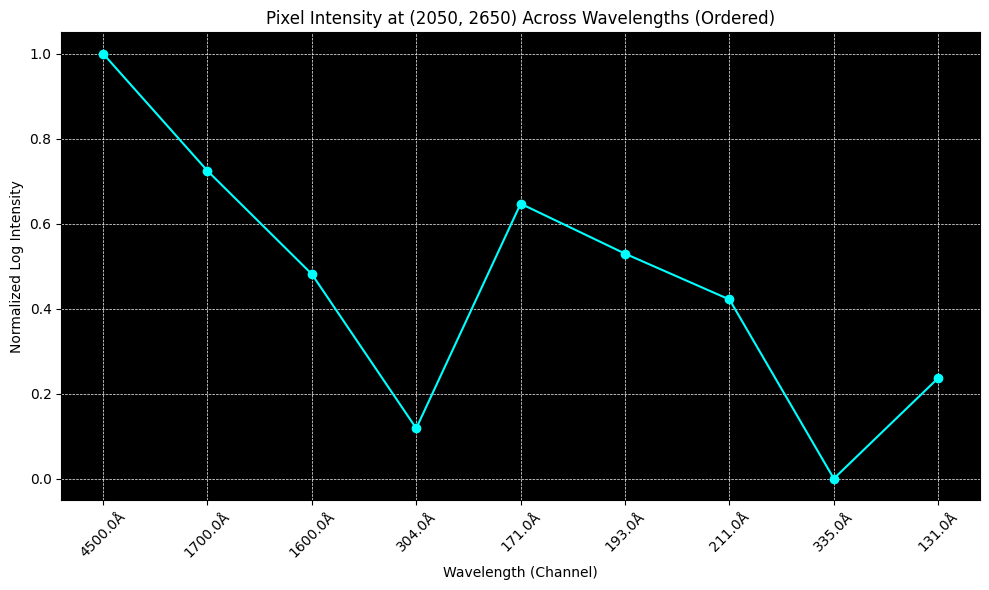

In [19]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
# Coordenadas del píxel que deseas analizar
pixel_x, pixel_y = 2050, 2650  # Cambia esto según las coordenadas que desees

# Orden de los canales desde la superficie solar hacia afuera
channel_order = [
    "4500.0Å", "1700.0Å", "1600.0Å", "304.0Å", 
    "171.0Å", "193.0Å", "211.0Å", "335.0Å", "131.0Å"
]

# Inicializar un diccionario para almacenar los valores del píxel procesados
pixel_values = {}

# Iterar sobre los canales para extraer y procesar el valor del píxel en cada longitud de onda
for channel in channel_order:
    if channel in channel_data_process:
        # Obtener los datos correspondientes al canal
        data = channel_data_process[channel].reshape(4096, 4096)  # Ajustar tamaño si es necesario
        
        # Verificar si las coordenadas están dentro de los límites
        if 0 <= pixel_x < data.shape[0] and 0 <= pixel_y < data.shape[1]:
            pixel_value = data[pixel_x, pixel_y]
            
            # Procesar el valor del píxel (log y normalización)
            if not np.isnan(pixel_value) and pixel_value > 0:
                pixel_values[channel] = np.log10(pixel_value)  # Aplicar logaritmo
            else:
                pixel_values[channel] = np.nan  # Asignar NaN si el valor no es válido
        else:
            pixel_values[channel] = np.nan  # Asignar NaN si las coordenadas están fuera de los límites

# Normalizar los valores procesados
channels_sorted = [ch for ch in channel_order if ch in pixel_values]  # Mantener el orden definido
values_sorted = [pixel_values[ch] for ch in channels_sorted]

# Filtrar valores válidos para la normalización
valid_indices = [i for i, v in enumerate(values_sorted) if not np.isnan(v)]
values_filtered = np.array([values_sorted[i] for i in valid_indices]).reshape(-1, 1)

# Normalizar usando MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_values = scaler.fit_transform(values_filtered)

# Reconstruir el arreglo con NaN donde los valores eran inválidos
final_values = [np.nan] * len(values_sorted)
for i, idx in enumerate(valid_indices):
    final_values[idx] = normalized_values[i, 0]

# Visualizar los valores del píxel en las diferentes longitudes de onda
plt.figure(figsize=(10, 6), facecolor="white")
plt.plot(channels_sorted, final_values, marker='o', color='cyan')
plt.title(f"Pixel Intensity at ({pixel_x}, {pixel_y}) Across Wavelengths (Ordered)", color="black")
plt.xlabel("Wavelength (Channel)", color="black")
plt.ylabel("Normalized Log Intensity", color="black")
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")
plt.grid(True, linestyle="--", linewidth=0.5, color="white")
plt.gca().set_facecolor("black")  # Fondo negro para los ejes
plt.tight_layout()
plt.show()


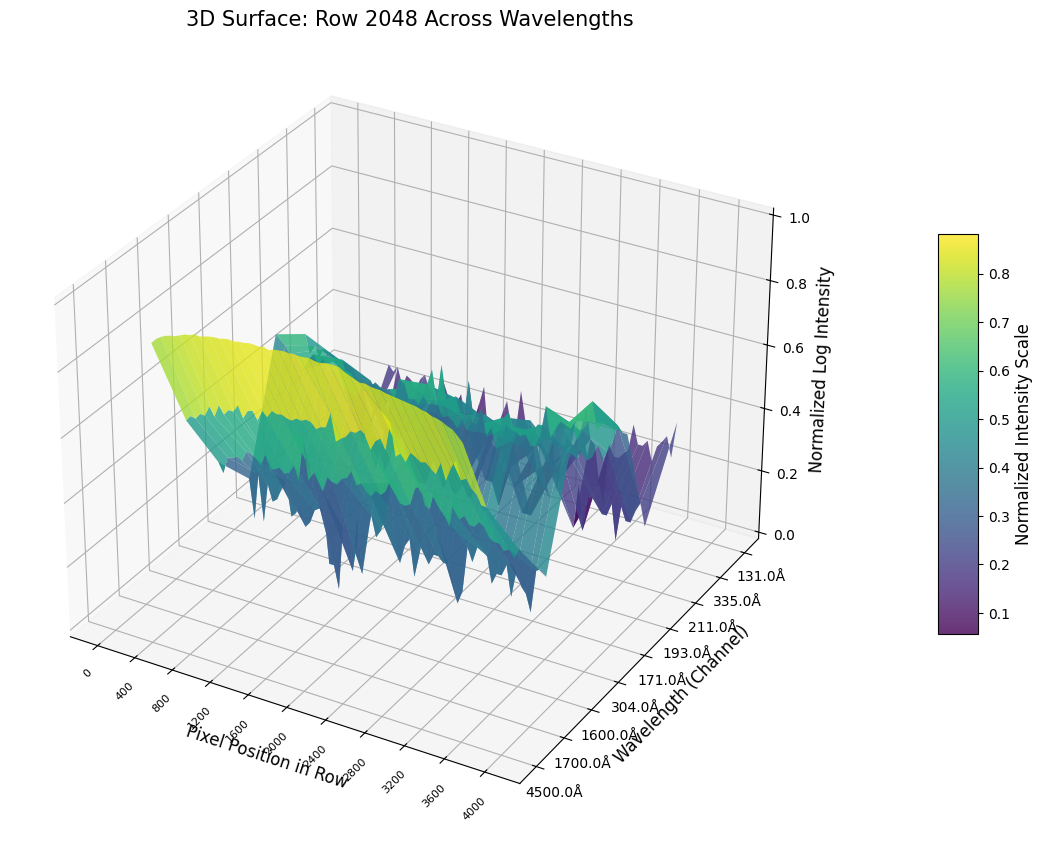

In [20]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

# Coordenadas del píxel y la fila a analizar
pixel_y = 2048  # Fila a analizar
step = 50  # Salto entre píxeles para mayor claridad

# Orden de los canales desde la superficie solar hacia afuera
channel_order = [
    "4500.0Å", "1700.0Å", "1600.0Å", "304.0Å", 
    "171.0Å", "193.0Å", "211.0Å", "335.0Å", "131.0Å"
]

# Recolectar todos los datos para normalización global
all_data = []
for channel in channel_order:
    if channel in channel_data_process:
        data = channel_data_process[channel].reshape(4096, 4096)
        row_data = data[pixel_y, ::step]
        valid_mask = (~np.isnan(row_data)) & (row_data > 0)
        log_row_data = np.log10(row_data[valid_mask]) if valid_mask.any() else np.array([])
        all_data.extend(log_row_data)

# Normalizar globalmente los datos
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array(all_data).reshape(-1, 1))

# Inicializar una lista para almacenar los datos procesados por canal
surface_data = []
for channel in channel_order:
    if channel in channel_data_process:
        data = channel_data_process[channel].reshape(4096, 4096)
        row_data = data[pixel_y, ::step]
        valid_mask = (~np.isnan(row_data)) & (row_data > 0)
        normalized_row = np.full(len(row_data), np.nan)
        if valid_mask.any():
            normalized_row[valid_mask] = scaler.transform(np.log10(row_data[valid_mask]).reshape(-1, 1)).flatten()
        surface_data.append(normalized_row)

# Convertir la superficie en un arreglo numpy
surface_data = np.array(surface_data)

# Crear la malla para la gráfica 3D
x = np.arange(0, surface_data.shape[1]) * step
y = np.arange(len(channel_order))
X, Y = np.meshgrid(x, y)

# Crear la gráfica 3D
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie
surf = ax.plot_surface(X, Y, surface_data, cmap='viridis', edgecolor='none', alpha=0.8)

# Ajustar etiquetas y escalas
ax.set_xticks(x[::max(1, len(x) // 10)])
ax.set_xticklabels(x[::max(1, len(x) // 10)], rotation=45, fontsize=8)
ax.set_yticks(np.arange(len(channel_order)))
ax.set_yticklabels(channel_order, fontsize=10)
ax.set_xlabel("Pixel Position in Row", fontsize=12)
ax.set_ylabel("Wavelength (Channel)", fontsize=12)
ax.set_zlabel("Normalized Log Intensity", fontsize=12)
ax.set_title(f"3D Surface: Row {pixel_y} Across Wavelengths", fontsize=15)

# Añadir barra de color
colorbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
colorbar.set_label("Normalized Intensity Scale", fontsize=12)

# Ajustar márgenes manualmente
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.show()


In [ ]:
1. **Notebook 1:**
 
   - Explorar diferentes técnicas de convolución para preprocesar las imágenes.
   - Implementar y evaluar el filtro gaussiano.
   - Probar otros métodos si es necesario.

